<a href="https://colab.research.google.com/github/DebbieArita/DataStructures-Algorithm-Python/blob/main/reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reward Run
A reinforcement learning (RL) demo game, made for the purposes of UPTECH AI course Theme 3: Machine Learning Fundamentals.
Blue dot (the agent) moves in a grid world (the environment). The goal of the agent is to reach the green dot.




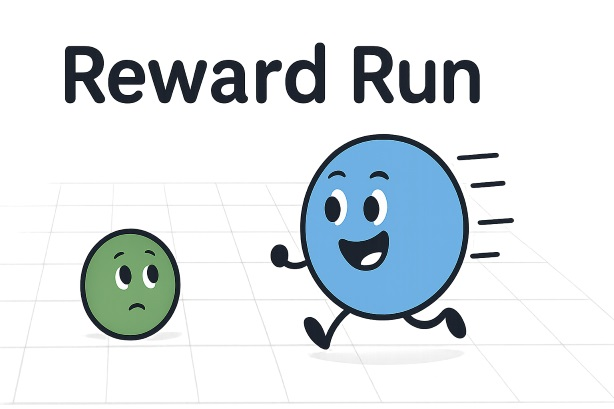



The following section imports the needed Python modules and defines the parameters of the game / simulation.

Feel free to play with the parameters and investigate how they affect the environment and the behaviour and learning of our agent!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import time

GRID_SIZE = 5
GOAL = (GRID_SIZE-1, GRID_SIZE-1)   # initial goal = top-right corner
EPISODES = 100            # number of training episodes - more episodes means more opportunity to learn
MAX_STEPS = 30            # maximum number of training steps per episode - prevents the agent from wandering forever
ALPHA   = 0.1             # learning rate - controls how much new information overrides old knowledge
GAMMA   = 0.9             # discount factor - balances immediate vs. future rewards.
EPSILON = 0.2             # probability of exploring new random actions
ACTIONS = ["up","down","left","right"]

Next section defines the environment and all the functions needed to run the simulation:
*   The step function – how the agent (blue dot) moves on the grid and receives feedback/reward.
*   The “cheat sheet” (Q-table) – where the agent stores what it has learned about each move.
*   The action choice – the agent can follow the cheat sheet or try a random move (exploration).
*   The learning rule (Q-learning) – how the "cheat sheet" is updated based on feedback and future expectations.
*   The visualization – so we can watch the agent learn in action!

In [ ]:
# --------------------------
# Environment
# --------------------------
def step(state, action, goal):
    r, c = state
    if action == "up"    and r < GRID_SIZE-1:   r += 1
    if action == "down"  and r > 0:             r -= 1
    if action == "left"  and c > 0:             c -= 1
    if action == "right" and c < GRID_SIZE-1:   c += 1
    ns = (r, c)
    reward = 10 if ns == goal else -1
    return ns, reward

# An empty Q-table
Q = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)))

def choose_action(s, eps=EPSILON):
    if np.random.rand() < eps:
        return np.random.randint(len(ACTIONS))
    return np.argmax(Q[s[0], s[1]])

def update_Q(s, a_idx, r, s2):
    best_next = np.max(Q[s2[0], s2[1]])
    Q[s[0], s[1], a_idx] += ALPHA * (r + GAMMA * best_next - Q[s[0], s[1], a_idx])

# --------------------------------------
# Visualization setup - drawing function
# --------------------------------------
def draw_state(s, goal, ep=None, total=None):
    agent_dot.set_data([s[1]], [s[0]])
    goal_dot.set_data([goal[1]], [goal[0]])
    if ep is not None:
        title.set_text(f"Episode {ep} | Return {total}")
    else:
        title.set_text("Demo")
    handle.update(fig)
    fig.canvas.draw()
    plt.pause(0.001) # so we could see what's going on in "real-time"

Now we can run the training loop, where in each of the EPISODES iterations (set to 100 by default) the agent has a chance to make a maximum of MAX_STEPS (set to 30 by default) moves.

Observe how its behavior changes as episodes go by, indicating that the agent is learning how to get to the green dot, by updating its "cheat sheet".


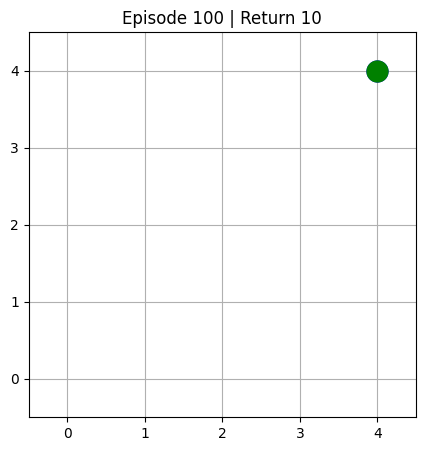

In [ ]:
# --------------------------
# Visualization setup - axes
# --------------------------

fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(-0.5, GRID_SIZE-0.5)
ax.set_ylim(-0.5, GRID_SIZE-0.5)
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.grid(True)

agent_dot, = ax.plot([], [], "bo", markersize=15)                   # blue agent
goal_dot,  = ax.plot([GOAL[1]], [GOAL[0]], "go", markersize=15)     # green goal
title = ax.set_title("")

handle = display(fig, display_id=True)
plt.close(fig)

# --------------------------
# Training
# --------------------------
rewards = []
for ep in range(1, EPISODES+1):
    s = (np.random.randint(GRID_SIZE), np.random.randint(GRID_SIZE))  # random start
    R = 0
    for t in range(MAX_STEPS):
        a_idx = choose_action(s)
        s2, r = step(s, ACTIONS[a_idx], GOAL)
        update_Q(s, a_idx, r, s2)
        s = s2
        R += r
        draw_state(s, GOAL, ep=ep, total=R)
        if s == GOAL:
            break
    rewards.append(R)


Now let's take a look in a bit slowed down simulation how the agent behaves, i.e. let's see what the agent has learned above!

Showing final learned behavior...


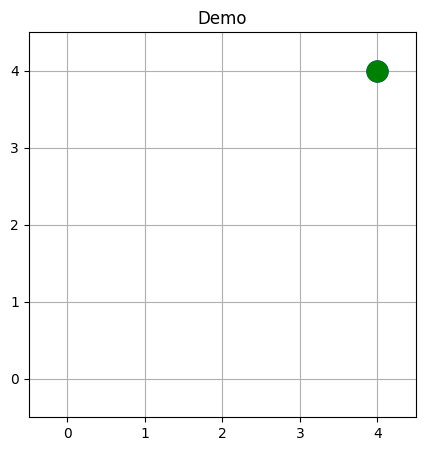

In [ ]:
# --------------------------
# Show final learned policy
# --------------------------
print("Showing final learned behavior...")

fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(-0.5, GRID_SIZE-0.5)
ax.set_ylim(-0.5, GRID_SIZE-0.5)
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.grid(True)

agent_dot, = ax.plot([], [], "bo", markersize=15)                   # blue agent
goal_dot,  = ax.plot([GOAL[1]], [GOAL[0]], "go", markersize=15)     # green goal
title = ax.set_title("")

handle = display(fig, display_id=True)
plt.close(fig)

def draw_state(s, goal, ep=None, total=None):
    agent_dot.set_data([s[1]], [s[0]])
    goal_dot.set_data([goal[1]], [goal[0]])
    if ep is not None:
        title.set_text(f"Episode {ep} | Return {total}")
    else:
        title.set_text("Demo")
    handle.update(fig)
    fig.canvas.draw()
    plt.pause(0.2) # slowed down simulation

s = (0, 0)  # bottom-left start
R = 0
for t in range(MAX_STEPS):
    a_idx = choose_action(s)
    s2, r = step(s, ACTIONS[a_idx], GOAL)
    update_Q(s, a_idx, r, s2)
    s = s2
    R += r
    draw_state(s, GOAL, total=R)
    if s == GOAL:
        break

The graph below shows the reward curve. Given the way we have written the reward system (-1 points for each move, 10 points for reaching the goal), a reward of -30 in an episode means the agent never reached its goal!

Those situations happen often in the initial episodes, but as the agent learns the right policy (strategy how to get to the goal) the rewards starts increasing - indicating learning is happening!

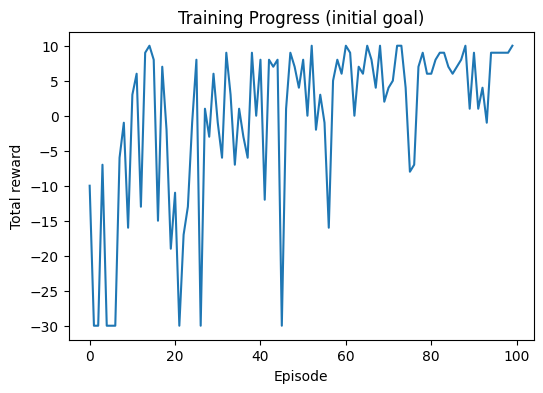

In [ ]:
# --------------------------
# Reward curve
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Training Progress (initial goal)")
plt.show()

Finnaly, we can take a sneak peek at the agents "cheat sheet" and see how that learned policy acutally looks like.

For most of the possible states (we have 25 possible states in a 5x5 grid), the "best move" should be to go either right or up (at least according to our human intuition). The agent has most likely learned something similar.


Visualizing learned policy...


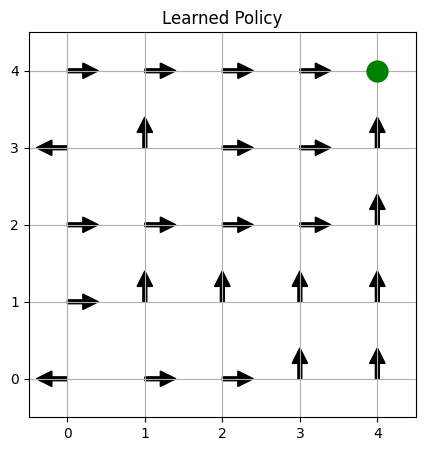

In [ ]:
# --------------------------
# Visualize learned policy
# --------------------------
print("\nVisualizing learned policy...")

# Create a figure and axes for the visualization
fig, ax = plt.subplots(figsize=(GRID_SIZE, GRID_SIZE))
ax.set_xlim(-0.5, GRID_SIZE-0.5)
ax.set_ylim(-0.5, GRID_SIZE-0.5)
ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.grid(True)
ax.set_title("Learned Policy")

# Define arrow parameters
arrow_width = 0.05
head_width = 0.2
head_length = 0.2
arrow_color = 'black'

# Iterate through each state in the grid
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        state = (r, c)
        # If the state is the goal, skip adding an arrow
        if state == GOAL:
            continue

        # Find the action with the highest Q-value for the current state
        best_action_idx = np.argmax(Q[r, c])
        best_action = ACTIONS[best_action_idx]

        # Determine the starting and ending points for the arrow based on the action
        start_x, start_y = c, r
        if best_action == "up":
            end_x, end_y = c, r + 0.4
        elif best_action == "down":
            end_x, end_y = c, r - 0.4
        elif best_action == "left":
            end_x, end_y = c - 0.4, r
        elif best_action == "right":
            end_x, end_y = c + 0.4, r
        else: # Should not happen
          continue

        # Add an arrow representing the best action from the state
        ax.arrow(start_x, start_y, end_x - start_x, end_y - start_y,
                 head_width=head_width, head_length=head_length, fc=arrow_color, ec=arrow_color,
                 length_includes_head=True, width=arrow_width)

# Add a green circle for the goal
ax.plot([GOAL[1]], [GOAL[0]], "go", markersize=15)

# Display the plot
plt.show()

And that's it! We saw how machines can learn in different ways, and how our little blue dot slowly figured out the best path to the green goal. Its “cheat sheet,” the Q-table, isn’t perfect, but it gets better with experience, showing us that learning is really just trial, error, and feedback. What’s most exciting is that in more complex worlds, **these same methods let agents discover clever strategies we might never think of ourselves**. That’s the real power of machine learning — it learns, adapts, and sometimes even surprises us with unexpected patterns and solutions!

If you’d like to build on this demo, there are many fun ways to make the environment more interesting. You could add **obstacles** on the grid, so the agent has to find **detours**. You could **change the reward system**, for example by giving small bonuses for getting closer to the goal, or adding penalties for bumping into walls. You could even **make the environment bigger**, or place multiple goals with different rewards, to see how the agent balances its choices. Each of these changes would challenge the learning process in new ways and give you a sense of how reinforcement learning scales up to more complex and realistic problems.
